## Importing libraries

In [268]:
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import os
import fiona
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd

In [269]:
print("Shapely:", shapely.__version__)
print("GeoPandas:", gpd.__version__)
print("Fiona:", fiona.__version__)

#Versions in the standard environment (environment1) for running the model have issues for reading the files with geopandas
#Updates are required and a copy environment (environment2) is used to execute this notebook (geopandas should be >0.10)

Shapely: 1.8.0
GeoPandas: 0.13.2
Fiona: 1.8.20


## Relevant file paths

In [324]:
#Load country map border
map_border =  str(os.path.dirname(os.getcwd())) + r'\\1. MSR Creator\\Input\\AllCountryBoundaries_GAUL.shp'

#Load rough MSR shapes for each technology (before cost assignement)
S1_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\1. MSR Creator\Output\Bolivia\Stage4_MSR\solarpv_FinalMSRs.shp'
S1_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\1. MSR Creator\Output\Bolivia\Stage4_MSR\wind_FinalMSRs.shp'

#Load prescreened MSR shapes (with LCOE and CAPEX values defined) 
S3_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_TandR_costs\SolarPV_prescreen.shp'
S3_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_TandR_costs\Wind_prescreen.shp'

#Load screened MSR data sets with hourly availabilities (for the top % of resources) 
S4_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\4. Screener\Results-Screened_Bolivia_TandR_costs\SolarPV_BestMSRsToCover5%CountryArea.shp'
S4_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\4. Screener\Results-Screened_Bolivia_TandR_costs\Wind_BestMSRsToCover5%CountryArea.shp'


In [271]:
with fiona.open(S3_MSR_pv_file) as src:
    print(src.schema)
    print(src.crs)
    print(len(src))

{'properties': OrderedDict([('FID', 'int:18'), ('AreakM2', 'float:24.15'), ('CapacityMW', 'float:24.15'), ('RoadDist', 'float:24.15'), ('T_Dist_gf', 'float:24.15'), ('D_Dist_gf', 'float:24.15'), ('TD_Dist_gf', 'float:24.15'), ('SubstnDist', 'float:24.15'), ('Load_dst', 'float:24.15'), ('City_name', 'str:80'), ('City_Pop', 'float:24.15'), ('CtLst100kM', 'str:80'), ('CtCnt100kM', 'int:18'), ('PopIn100kM', 'float:24.15'), ('Elev_mean', 'float:24.15'), ('Elev_max', 'float:24.15'), ('Elev_centr', 'float:24.15'), ('CtryName', 'str:80'), ('GHIkWhm2d', 'str:80'), ('RawERA_GHI', 'float:24.15'), ('CorAdderWh', 'float:24.15'), ('CF', 'float:24.15'), ('Y_GWh', 'float:24.15'), ('sLCOE-MWh', 'float:24.15'), ('sCAPEX-kW', 'float:24.15'), ('tLCOE-MWh', 'float:24.15'), ('tCAPEX-kW', 'float:24.15'), ('rLCOE-MWh', 'float:24.15'), ('rCAPEX-kW', 'float:24.15'), ('LCOE-MWh', 'float:24.15'), ('trCAPEX-kW', 'float:24.15'), ('TotalCAPEX', 'float:24.15')]), 'geometry': 'Polygon'}
{}
2543


In [272]:
# Read data without geometry (to work with environment1) 
gdf_test = gpd.read_file(S3_MSR_pv_file, ignore_geometry=True)
gdf_test.head()

,FID,AreakM2,CapacityMW,RoadDist,T_Dist_gf,D_Dist_gf,TD_Dist_gf,SubstnDist,Load_dst,City_name,...,Y_GWh,sLCOE-MWh,sCAPEX-kW,tLCOE-MWh,tCAPEX-kW,rLCOE-MWh,rCAPEX-kW,LCOE-MWh,trCAPEX-kW,TotalCAPEX
0,0,586.872314,1936.678637,1.375914,72.728027,3.134096,3.134096,72.312984,32.234810,Desaguadero,...,4002.038336,52.868515,78.549835,10.485952,21.668635,2.606487,5.386161,65.960954,27.054796,105.604631
1,1,23.598726,77.875797,3.914754,65.164544,4.643749,4.643749,65.099316,16.419285,Desaguadero,...,163.348832,52.084351,78.549835,9.641260,20.223081,7.305989,15.324720,69.031600,35.547801,114.097637
2,2,691.800213,2282.940704,1.953428,85.493819,3.570420,3.570420,85.114797,57.735726,Desaguadero,...,4732.452340,52.702252,78.549835,11.629955,24.108470,3.688874,7.646901,68.021081,31.755371,110.305206
3,3,611.000948,2016.303129,2.763195,101.957641,4.259289,4.259289,101.840049,84.548106,Desaguadero,...,4149.344967,53.088087,78.549835,13.244140,27.255082,5.256249,10.816822,71.588476,38.071904,116.621739
4,4,712.973166,2352.811449,1.909492,121.268679,7.149950,7.149950,124.426456,112.096212,Desaguadero,...,4955.474534,51.870767,78.549835,14.692797,30.945863,3.549014,7.474908,70.112578,38.420771,116.970606


## Plotting functions

In [273]:
def region_map (geo_dataframe, country, key_column, map_title):
    """
    Creates a simple heat map of a specific country for the selected column/parameter.
    """
    gdfmap = gpd.read_file(map_border)
    gdf_country = gdfmap[gdfmap['name'] == country]

    ax = geo_dataframe.plot(column=key_column, legend=True, figsize=(8,6), cmap='viridis')
    gdf_country.boundary.plot(ax=ax, edgecolor='black', linewidth=1)
    
    plt.title(map_title)
    plt.show()


In [274]:
def plot_variable_relationship(dataframe, col_x, col_y, add_regression=True):
    """
    Plots the relationship between two variables in a dataframe.
    
    Parameters:
    - df: pandas DataFrame
    - col_x: column name for the independent variable (x-axis)
    - col_y: column name for the dependent variable (y-axis)
    - add_regression: if True, adds a linear regression line
    """

    x = pd.to_numeric(dataframe[col_x], errors="coerce").to_numpy().ravel()
    y = pd.to_numeric(dataframe[col_y], errors="coerce").to_numpy().ravel()

    # ---- FIX: remove non-finite values before regression ----
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    # --- Compute Pearson & Spearman correlations ---
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)

    print(f"\n===== Correlation Analysis: {col_x} vs {col_y} =====")
    print(f"Pearson r:     {pearson_r:.4f}  (p = {pearson_p:.4e})")
    print(f"Spearman rho:  {spearman_rho:.4f}  (p = {spearman_p:.4e})")
    print("=====================================================\n")

    fig, ax = plt.subplots(figsize=(8, 4))

    # Scatter plot
    ax.scatter(x, y, color='blue', alpha=0.6, edgecolor='k', s=60)
    
    # Optional: add linear regression
    if add_regression:
        coeffs = np.polyfit(x, y, deg=1)  # linear regression
        y_fit = np.polyval(coeffs, x)
        ax.plot(x, y_fit, color='red', linestyle='--', linewidth=2,
                label=f'Linear fit: y={coeffs[0]:.2f}x + {coeffs[1]:.2f}')
        ax.legend()
        
    # Add correlation info on the plot (top-left corner)
    corr_text = (
        f"Pearson r = {pearson_r:.3f}\n"
        f"Spearman ρ = {spearman_rho:.3f}"
    )
    ax.text(
        0.02, 0.98, corr_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
    )

    ax.set_title(f"Relationship between {col_x} and {col_y}")
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)
    ax.grid(True)
    
    plt.show()


In [275]:
def generate_supply_curve(geo_dataframe,ranking_col,accumulation_col,ascending=True,):
    """
    Creates a supply curve by sorting a dataframe (geo_dataframe) based on [ranking_col] and 
    accumulating values based on [accumulation_col], using matplotlib.
    """

    # Copy to avoid altering original
    df = geo_dataframe[[ranking_col, accumulation_col]].copy()

    # Sort by chosen metric
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)

    # Create cumulative sum
    df["cumulative"] = df[accumulation_col].cumsum()

    # Matplotlib figure
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(df["cumulative"], df[ranking_col], marker='o', linestyle='-')
    
    ax.set_title(f"Supply Curve: {ranking_col} vs cumulative {accumulation_col}")
    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(f"{ranking_col}")

    ax.grid(True)
    
    plt.show()

In [276]:
def generate_supply_curve_color(geo_dataframe, ranking_col, accumulation_col, third_col,
                                ascending=True, cmap="viridis"):
    df = geo_dataframe[[ranking_col, accumulation_col, third_col]].copy()
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)
    df["cumulative"] = df[accumulation_col].cumsum()

    fig, ax = plt.subplots(figsize=(8, 4))

    sc = ax.scatter(
        df["cumulative"],
        df[ranking_col],
        c=df[third_col],
        cmap=cmap
    )

    ax.plot(df["cumulative"], df[ranking_col], alpha=0.3)  # keep curve shape visible

    cbar = plt.colorbar(sc)
    cbar.set_label(third_col)

    ax.set_title(f"Supply Curve Colored by {third_col}")
    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(ranking_col)
    ax.grid(True)

    plt.show()

    return df


In [277]:
from mpl_toolkits.mplot3d import Axes3D

def generate_supply_curve_3d(geo_dataframe, ranking_col, accumulation_col, third_col,
                             ascending=True):
    """
    3D supply curve: cumulative vs ranking vs third variable.
    """
    
    df = geo_dataframe[[ranking_col, accumulation_col, third_col]].copy()
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)
    df["cumulative"] = df[accumulation_col].cumsum()
    
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(
        df["cumulative"], 
        df[ranking_col], 
        df[third_col],
        c=df[third_col],
        s=3
    )

    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(ranking_col)
    ax.set_zlabel(third_col)
    ax.set_title(f"3D Supply Curve with {third_col}")

    plt.show()

    return df


In [278]:
def generate_supply_curve_3d_band_analysis(geo_dataframe, ranking_col,
                                           accumulation_col, third_col,
                                           n_bands, ascending=True, 
                                           cmap="viridis"):
    """
    3D supply curve band analysis based on quantiles of third_col.
    Creates n_bands supply curves (bands) based on quantile ranges of the third variable.
    """

    df = geo_dataframe[[ranking_col, accumulation_col, third_col]].copy()

    # Create quantile bands
    df["band"] = pd.qcut(df[third_col], q=n_bands, labels=False, duplicates="drop")
    df = df.dropna(subset=["band"])

    # Prepare figure
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection="3d")

    # Choose color map
    colors = plt.cm.get_cmap(cmap, n_bands)

    # Plot each band separately
    for band in sorted(df["band"].unique()):
        df_band = df[df["band"] == band].copy()
        df_band = df_band.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)
        df_band["cumulative"] = df_band[accumulation_col].cumsum()

        # Use average altitude (or third_col) for the whole curve
        z_val = df_band[third_col].mean()
        z_array = np.full_like(df_band["cumulative"], fill_value=z_val)

        ax.plot(
            df_band["cumulative"],
            df_band[ranking_col],
            z_array,#df_band["band"],
            label=f"Band {band} (mean quantile value = {z_val:.2f})",
            #color=colors(band)
        )

        # optional: scatter for points
        ax.scatter(
            df_band["cumulative"],
            df_band[ranking_col],
            df_band[third_col],
            #color=colors(band),
            s=3,
            alpha=0.5,
            depthshade=True,
        )
    
    # ax.zaxis._axinfo["grid"]['linewidth'] = 0.5
    # ax.zaxis._axinfo["grid"]['color'] = (0.5,0.5,0.5,0.3)

    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)

    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(ranking_col)
    ax.set_zlabel(third_col)
    ax.set_title(f"3D Supply Curve Band Analysis by {third_col}")

    ax.legend(fontsize=5) #'small'
    plt.show()

    return df

In [279]:
def generate_supply_curve_3d_definedband_analysis(
    geo_dataframe,
    ranking_col,
    accumulation_col,
    third_col,
    band_edges,               # <-- user-defined
    ascending=True,
    cmap="viridis"
):
    """
    3D supply curve band analysis using user-defined bands of third_col.

    Parameters
    ----------
    band_edges : list or array
        Monotonically increasing bin edges for third_col
        e.g. [0, 200, 500, 1000, np.inf]
    """

    df = geo_dataframe[[ranking_col, accumulation_col, third_col]].copy()

    # Create bands using explicit thresholds
    df["band"] = pd.cut(
        df[third_col],
        bins=band_edges,
        labels=False,
        include_lowest=True
    )

    df = df.dropna(subset=["band"])
    df["band"] = df["band"].astype(int)

    # Prepare figure
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection="3d")

    n_bands = len(band_edges) - 1
    colors = plt.cm.get_cmap(cmap, n_bands)

    for band in sorted(df["band"].unique()):
        df_band = df[df["band"] == band].copy()
        df_band = df_band.sort_values(
            ranking_col, ascending=ascending
        ).reset_index(drop=True)

        df_band["cumulative"] = df_band[accumulation_col].cumsum()

        z_val = df_band[third_col].mean()
        z_array = np.full(len(df_band), z_val)

        ax.plot(
            df_band["cumulative"],
            df_band[ranking_col],
            z_array,
            label=f"Band {band} [{band_edges[band]}, {band_edges[band+1]})",
            color=colors(band)
        )

        ax.scatter(
            df_band["cumulative"],
            df_band[ranking_col],
            df_band[third_col],
            color=colors(band),
            s=3,
            alpha=0.5,
            depthshade=True
        )

    ax.xaxis.pane.set_alpha(0.0)
    ax.yaxis.pane.set_alpha(0.0)
    ax.zaxis.pane.set_alpha(0.0)

    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(ranking_col)
    ax.set_zlabel(third_col)
    ax.set_title(f"3D Supply Curve Band Analysis by {third_col}")

    ax.legend(fontsize=6)
    plt.show()

    return df


## Basic file exploration

In [280]:
gdf3wind = gpd.read_file(S3_MSR_wind_file)
gdf3solar = gpd.read_file(S3_MSR_pv_file)

#check cordinate reference system and change it to WGS84 ellipsoid
gdf3wind = gdf3wind.to_crs("EPSG:4326")
gdf3solar = gdf3solar.to_crs("EPSG:4326")
#gdf3solar.crs

In [321]:
gdf3solar.info()
gdf3solar.columns
#gdf3wind.info()
#gdf3wind.columns

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2543 entries, 0 to 2542
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         2543 non-null   int64   
 1   AreakM2     2543 non-null   float64 
 2   CapacityMW  2543 non-null   float64 
 3   RoadDist    2543 non-null   float64 
 4   T_Dist_gf   2543 non-null   float64 
 5   D_Dist_gf   2543 non-null   float64 
 6   TD_Dist_gf  2543 non-null   float64 
 7   SubstnDist  2543 non-null   float64 
 8   Load_dst    2543 non-null   float64 
 9   City_name   2543 non-null   object  
 10  City_Pop    2543 non-null   float64 
 11  CtLst100kM  1867 non-null   object  
 12  CtCnt100kM  2543 non-null   int64   
 13  PopIn100kM  2543 non-null   float64 
 14  Elev_mean   2540 non-null   float64 
 15  Elev_max    2540 non-null   float64 
 16  Elev_centr  2543 non-null   float64 
 17  CtryName    2543 non-null   object  
 18  GHIkWhm2d   2543 non-null   object  
 19

Index(['FID', 'AreakM2', 'CapacityMW', 'RoadDist', 'T_Dist_gf', 'D_Dist_gf',
       'TD_Dist_gf', 'SubstnDist', 'Load_dst', 'City_name', 'City_Pop',
       'CtLst100kM', 'CtCnt100kM', 'PopIn100kM', 'Elev_mean', 'Elev_max',
       'Elev_centr', 'CtryName', 'GHIkWhm2d', 'RawERA_GHI', 'CorAdderWh', 'CF',
       'Y_GWh', 'sLCOE-MWh', 'sCAPEX-kW', 'tLCOE-MWh', 'tCAPEX-kW',
       'rLCOE-MWh', 'rCAPEX-kW', 'LCOE-MWh', 'trCAPEX-kW', 'TotalCAPEX',
       'geometry'],
      dtype='object')

In [282]:
height = gdf3wind["Elev_mean"]

In [283]:
gdf3solar.columns

Index(['FID', 'AreakM2', 'CapacityMW', 'RoadDist', 'T_Dist_gf', 'D_Dist_gf',
       'TD_Dist_gf', 'SubstnDist', 'Load_dst', 'City_name', 'City_Pop',
       'CtLst100kM', 'CtCnt100kM', 'PopIn100kM', 'Elev_mean', 'Elev_max',
       'Elev_centr', 'CtryName', 'GHIkWhm2d', 'RawERA_GHI', 'CorAdderWh', 'CF',
       'Y_GWh', 'sLCOE-MWh', 'sCAPEX-kW', 'tLCOE-MWh', 'tCAPEX-kW',
       'rLCOE-MWh', 'rCAPEX-kW', 'LCOE-MWh', 'trCAPEX-kW', 'TotalCAPEX',
       'geometry'],
      dtype='object')

In [284]:
#gdf3solar.head()
gdf3wind.head()

,FID,AreakM2,CapacityMW,RoadDist,T_Dist_gf,D_Dist_gf,TD_Dist_gf,SubstnDist,Load_dst,City_name,...,CF100m,Y_GWh100m,sLCOE-MWh,tLCOE-MWh,tCAPEX-kW,rLCOE-MWh,rCAPEX-kW,LCOE-MWh,trCAPEX-kW,geometry
0,0,152.806260,449.250405,1.201183,4.121323,2.393051,2.393051,8.756527,21.379872,Montero,...,44.910324,1767.415960,46.725910,2.174889,83.672753,1.195218,42.681696,50.096017,126.354450,"POLYGON ((-63.38956 -17.46986, -63.38647 -17.4..."
1,1,209.618699,616.278976,1.244803,3.557781,2.410556,2.410556,13.902395,15.999640,Santa Cruz1,...,46.442773,2507.261331,45.184119,2.076651,82.619494,1.197751,44.231626,48.458521,126.851120,"POLYGON ((-63.41391 -17.61098, -63.41082 -17.6..."
2,2,22.950870,67.475558,0.711849,8.316513,0.888841,0.888841,12.214981,10.721693,Santa Cruz1,...,43.936656,259.703375,41.075066,2.431407,91.513563,0.724010,25.294153,44.230483,116.807716,"POLYGON ((-63.32942 -17.87104, -63.33174 -17.8..."
3,3,278.516488,818.838475,0.608752,1.425254,1.252322,1.252322,0.916361,24.486972,Montero,...,45.012359,3228.747794,46.619991,2.039279,78.633801,0.604355,21.630794,49.263625,100.264594,"POLYGON ((-63.25947 -17.55403, -63.25893 -17.5..."
4,4,271.242689,797.453505,0.618861,1.412408,2.200173,1.412408,5.834439,10.718776,Santa Cruz1,...,40.991492,2863.539692,44.026234,2.238629,78.609790,0.674658,21.990023,46.939521,100.599812,"POLYGON ((-63.28986 -17.72242, -63.28932 -17.7..."


## Data analysis (for prescreend or S3 data)

In [329]:
gdf3wind = gpd.read_file(S3_MSR_wind_file)
gdf3solar = gpd.read_file(S3_MSR_pv_file)

#check cordinate reference system and change it to WGS84 ellipsoid
gdf3wind = gdf3wind.to_crs("EPSG:4326")
gdf3solar = gdf3solar.to_crs("EPSG:4326")
#gdf3solar.crs

In [330]:
gdf3solar.info()
gdf3wind.columns
#gdf3wind.info()
#gdf3wind.columns

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2543 entries, 0 to 2542
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         2543 non-null   int64   
 1   AreakM2     2543 non-null   float64 
 2   CapacityMW  2543 non-null   float64 
 3   RoadDist    2543 non-null   float64 
 4   T_Dist_gf   2543 non-null   float64 
 5   D_Dist_gf   2543 non-null   float64 
 6   TD_Dist_gf  2543 non-null   float64 
 7   SubstnDist  2543 non-null   float64 
 8   Load_dst    2543 non-null   float64 
 9   City_name   2543 non-null   object  
 10  City_Pop    2543 non-null   float64 
 11  CtLst100kM  1867 non-null   object  
 12  CtCnt100kM  2543 non-null   int64   
 13  PopIn100kM  2543 non-null   float64 
 14  Elev_mean   2540 non-null   float64 
 15  Elev_max    2540 non-null   float64 
 16  Elev_centr  2543 non-null   float64 
 17  CtryName    2543 non-null   object  
 18  GHIkWhm2d   2543 non-null   object  
 19

Index(['FID', 'AreakM2', 'CapacityMW', 'RoadDist', 'T_Dist_gf', 'D_Dist_gf',
       'TD_Dist_gf', 'SubstnDist', 'Load_dst', 'City_name', 'City_Pop',
       'CtLst100kM', 'CtCnt100kM', 'PopIn100kM', 'Elev_mean', 'Elev_max',
       'Elev_centr', 'CtryName', 'MeanSpeed', 'IEC_Class', 'ERA_WSpeed',
       'CF100m', 'Y_GWh100m', 'sLCOE-MWh', 'sCAPEX-kW', 'tLCOE-MWh',
       'tCAPEX-kW', 'rLCOE-MWh', 'rCAPEX-kW', 'LCOE-MWh', 'trCAPEX-kW',
       'TotalCAPEX', 'geometry'],
      dtype='object')

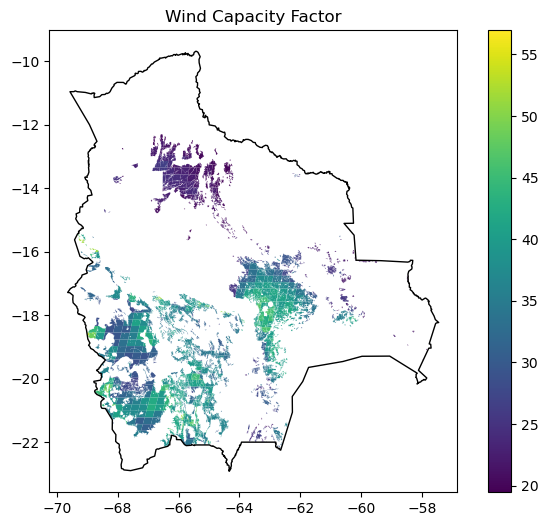

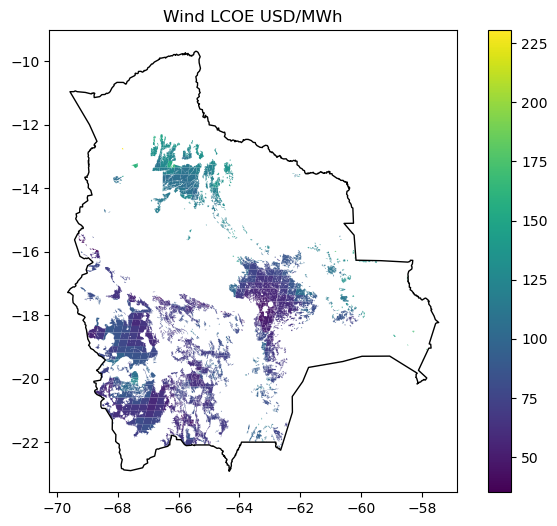

In [287]:
region_map(geo_dataframe=gdf3wind, country='Bolivia', key_column="CF100m", map_title="Wind Capacity Factor")
region_map(geo_dataframe=gdf3wind, country='Bolivia', key_column="LCOE-MWh", map_title="Wind LCOE USD/MWh")


===== Correlation Analysis: CF100m vs LCOE-MWh =====
Pearson r:     -0.9255  (p = 0.0000e+00)
Spearman rho:  -0.9580  (p = 0.0000e+00)



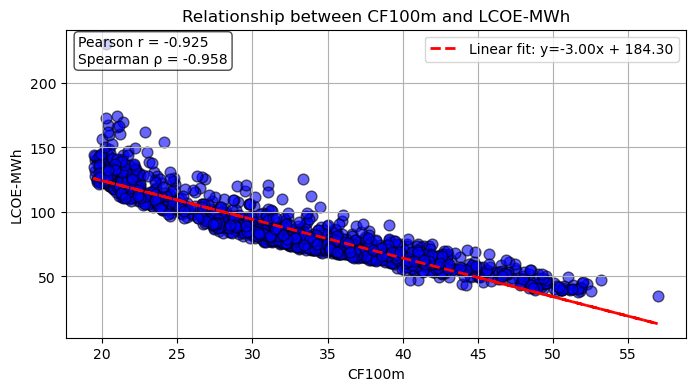


===== Correlation Analysis: T_Dist_gf vs LCOE-MWh =====
Pearson r:     0.5046  (p = 4.3122e-92)
Spearman rho:  0.4966  (p = 8.2789e-89)



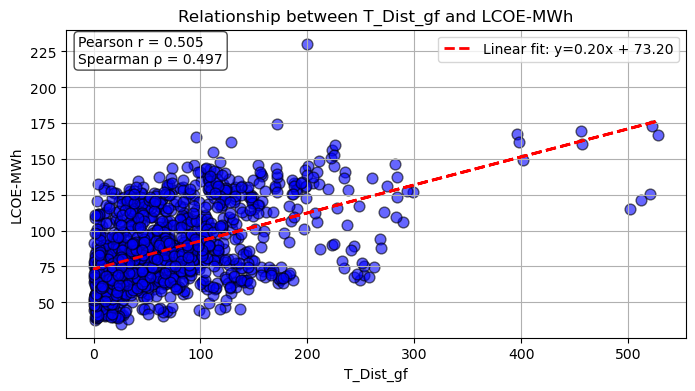


===== Correlation Analysis: RoadDist vs LCOE-MWh =====
Pearson r:     0.1770  (p = 2.1231e-11)
Spearman rho:  0.1030  (p = 1.0552e-04)



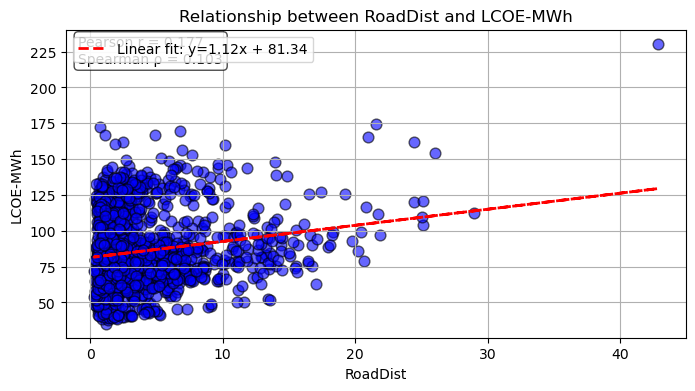


===== Correlation Analysis: T_Dist_gf vs CF100m =====
Pearson r:     -0.3157  (p = 4.7829e-34)
Spearman rho:  -0.3710  (p = 2.6114e-47)



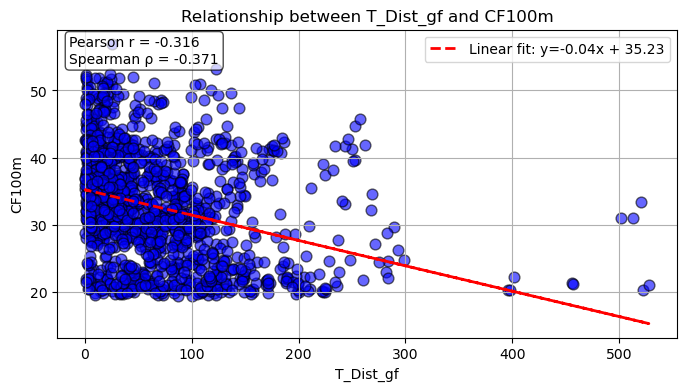


===== Correlation Analysis: Elev_mean vs LCOE-MWh =====
Pearson r:     -0.5280  (p = 3.8933e-102)
Spearman rho:  -0.5402  (p = 1.0113e-107)



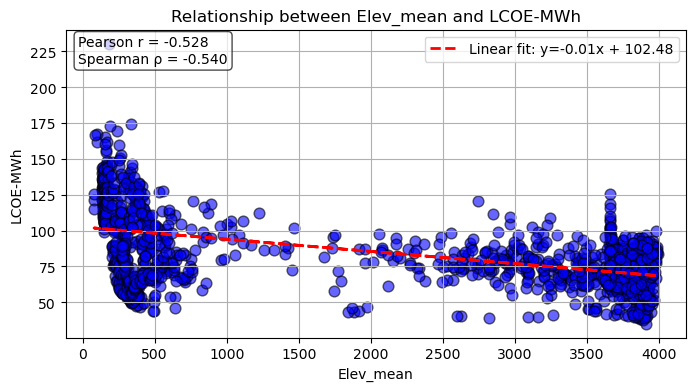

In [288]:
plot_variable_relationship(dataframe=gdf3wind, col_x='CF100m',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf3wind, col_x='T_Dist_gf',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf3wind, col_x='RoadDist',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf3wind, col_x='T_Dist_gf',col_y='CF100m',add_regression=True)
plot_variable_relationship(dataframe=gdf3wind, col_x='Elev_mean',col_y='LCOE-MWh',add_regression=True)

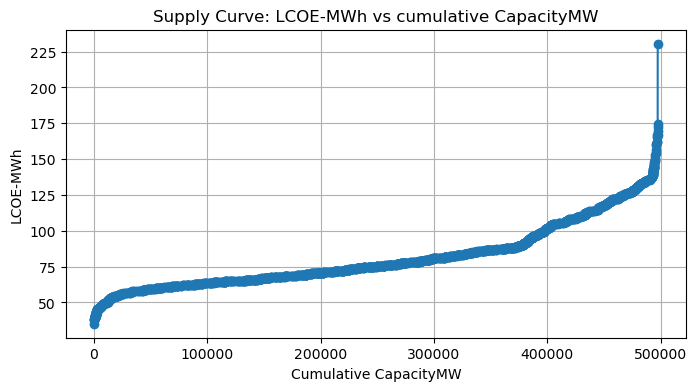

In [289]:
#generate_supply_curve(geo_dataframe=gdf3wind,ranking_col="CF100m",accumulation_col="CapacityMW",ascending=False)
generate_supply_curve(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",ascending=True)
#generate_supply_curve(geo_dataframe=gdf3wind,ranking_col="TD_Dist_gf",accumulation_col="CapacityMW",ascending=True)
#generate_supply_curve(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="Y_GWh100m",ascending=True)

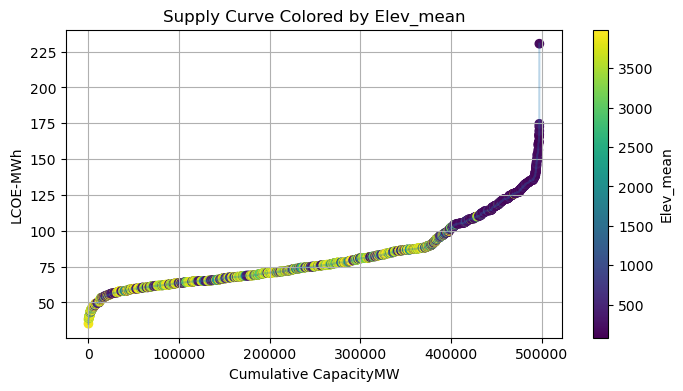

,LCOE-MWh,CapacityMW,Elev_mean,cumulative
0,35.117358,22.049100,3909.555556,22.049100
1,37.864623,97.759863,3886.562500,119.808963
2,38.654596,129.106776,3865.375000,248.915739
3,38.739010,103.604203,3894.531250,352.519942
4,39.096567,101.478989,2819.147059,453.998931
...,...,...,...,...
1407,167.118563,33.737779,99.250000,497270.147209
1408,169.663845,69.069469,237.913043,497339.216677
1409,172.721755,25.768225,187.300000,497364.984902
1410,174.594385,33.472127,338.142857,497398.457029


In [290]:
#generate_supply_curve_color(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="TD_Dist_gf", ascending=True)
generate_supply_curve_color(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ascending=True)

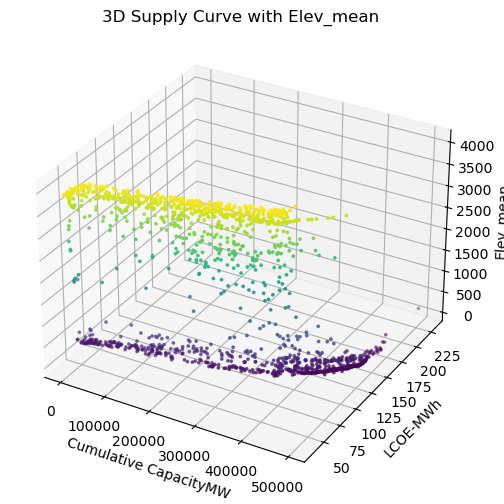

,LCOE-MWh,CapacityMW,Elev_mean,cumulative
0,35.117358,22.049100,3909.555556,22.049100
1,37.864623,97.759863,3886.562500,119.808963
2,38.654596,129.106776,3865.375000,248.915739
3,38.739010,103.604203,3894.531250,352.519942
4,39.096567,101.478989,2819.147059,453.998931
...,...,...,...,...
1407,167.118563,33.737779,99.250000,497270.147209
1408,169.663845,69.069469,237.913043,497339.216677
1409,172.721755,25.768225,187.300000,497364.984902
1410,174.594385,33.472127,338.142857,497398.457029


In [291]:
generate_supply_curve_3d(geo_dataframe=gdf3wind, ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ascending=True)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_36884\2190700042.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cmap, n_bands)


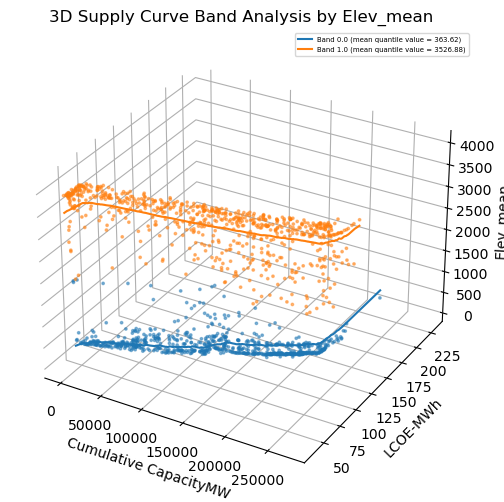

In [292]:
data_test = generate_supply_curve_3d_band_analysis(geo_dataframe=gdf3wind, 
                                       ranking_col="LCOE-MWh",
                                       accumulation_col="CapacityMW",
                                       third_col="Elev_mean", 
                                       n_bands=2, ascending=True, 
                                       cmap="viridis")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_36884\3988394567.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cmap, n_bands)


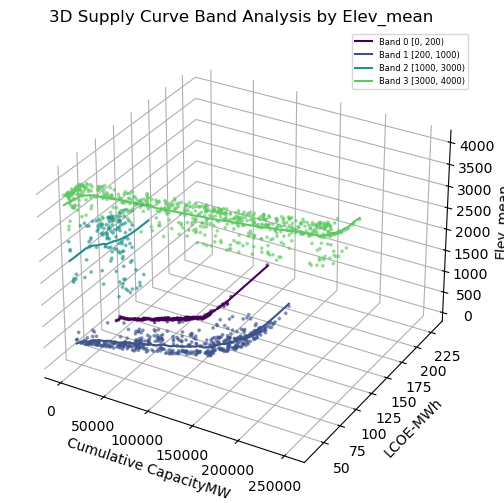

,LCOE-MWh,CapacityMW,Elev_mean,band
0,50.096017,449.250405,345.340136,1
1,48.458521,616.278976,410.770000,1
2,44.230483,67.475558,493.705882,1
3,49.263625,818.838475,336.812057,1
4,46.939521,797.453505,395.721254,1
...,...,...,...,...
1406,62.044639,180.377574,3411.984375,3
1408,86.535365,47.286021,272.200000,1
1409,70.280626,1188.791817,3788.155718,3
1410,89.832376,22.580403,277.666667,1


In [293]:
band_edges = [0, 200, 1000, 3000, 4000, np.inf]

generate_supply_curve_3d_definedband_analysis(
    geo_dataframe=gdf3wind,
    ranking_col="LCOE-MWh",
    accumulation_col="CapacityMW",
    third_col="Elev_mean",
    band_edges=band_edges
)


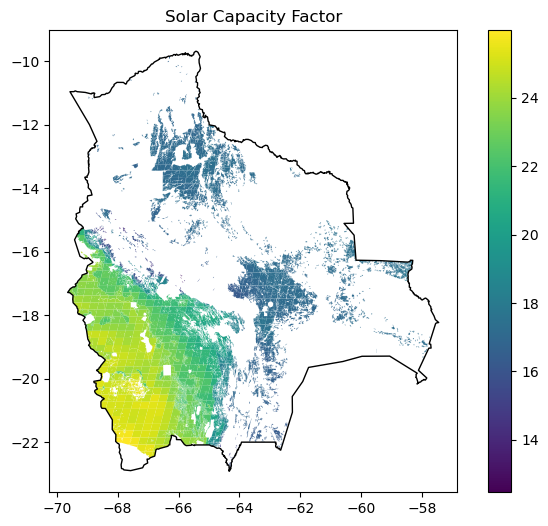

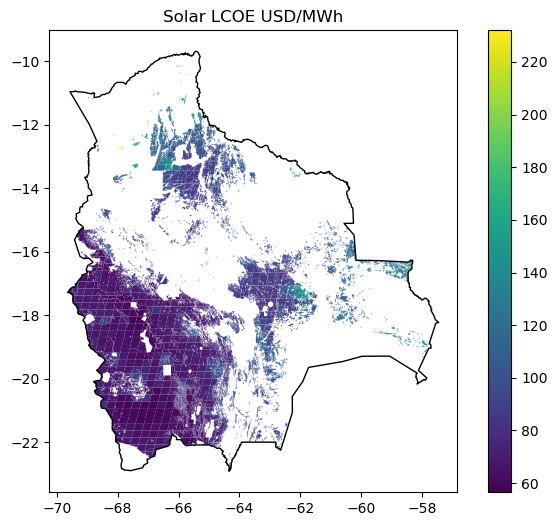

In [294]:
region_map(geo_dataframe=gdf3solar, country='Bolivia', key_column="CF", map_title="Solar Capacity Factor")
region_map(geo_dataframe=gdf3solar, country='Bolivia', key_column="LCOE-MWh", map_title="Solar LCOE USD/MWh")


===== Correlation Analysis: CF vs LCOE-MWh =====
Pearson r:     -0.6679  (p = 0.0000e+00)
Spearman rho:  -0.6514  (p = 4.2812e-307)



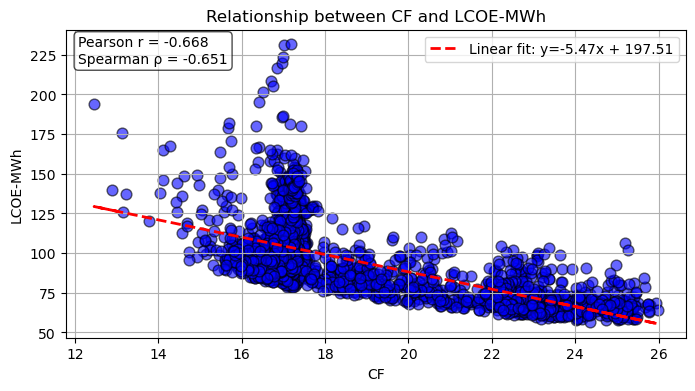


===== Correlation Analysis: T_Dist_gf vs LCOE-MWh =====
Pearson r:     0.6819  (p = 0.0000e+00)
Spearman rho:  0.7054  (p = 0.0000e+00)



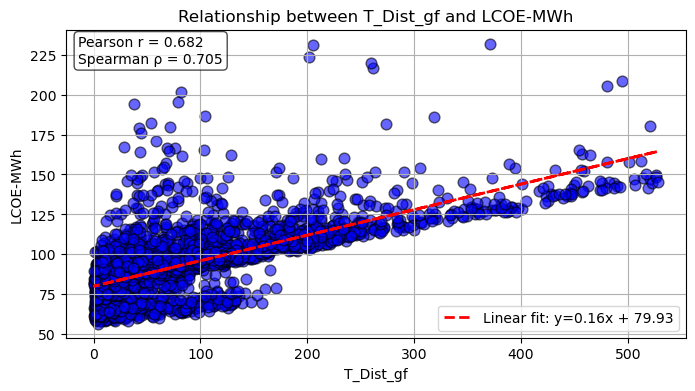


===== Correlation Analysis: RoadDist vs LCOE-MWh =====
Pearson r:     0.5184  (p = 6.2655e-175)
Spearman rho:  0.2572  (p = 1.0665e-39)



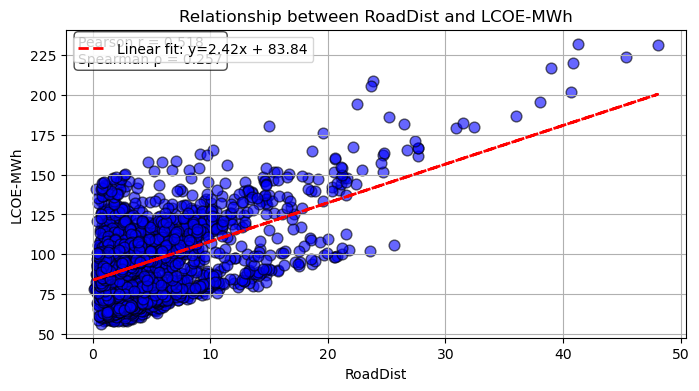


===== Correlation Analysis: T_Dist_gf vs CF =====
Pearson r:     -0.3098  (p = 1.0827e-57)
Spearman rho:  -0.2612  (p = 6.3436e-41)



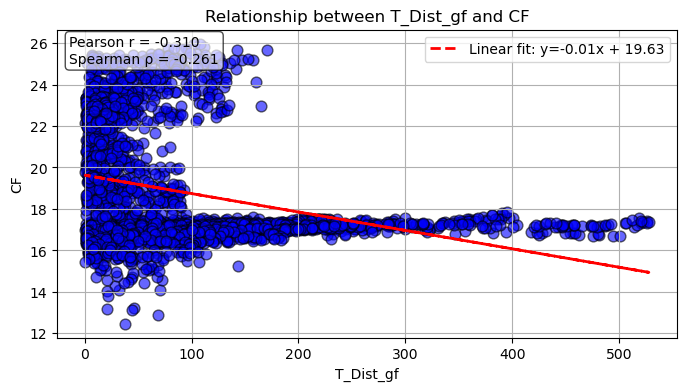


===== Correlation Analysis: Elev_mean vs LCOE-MWh =====
Pearson r:     -0.6361  (p = 3.7460e-288)
Spearman rho:  -0.6643  (p = 3.9525e-323)



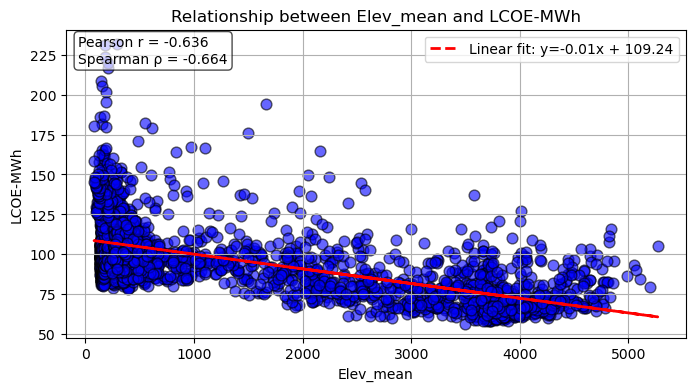

In [295]:
plot_variable_relationship(dataframe=gdf3solar, col_x='CF',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf3solar, col_x='T_Dist_gf',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf3solar, col_x='RoadDist',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf3solar, col_x='T_Dist_gf',col_y='CF',add_regression=True)
plot_variable_relationship(dataframe=gdf3solar, col_x='Elev_mean',col_y='LCOE-MWh',add_regression=True)

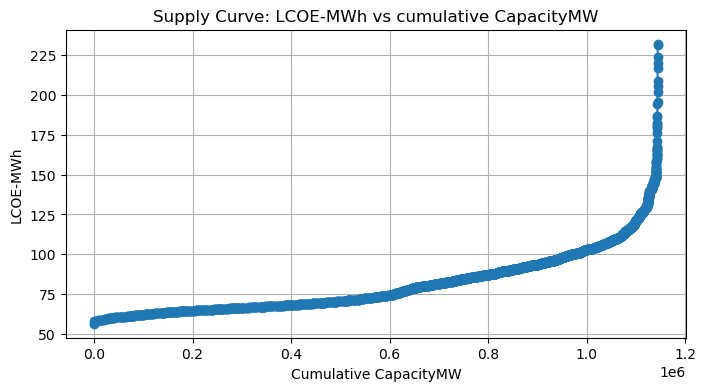

In [296]:
#generate_supply_curve(geo_dataframe=gdf3solar,ranking_col="CF",accumulation_col="CapacityMW",ascending=False)
generate_supply_curve(geo_dataframe=gdf3solar,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",ascending=True)
#generate_supply_curve(geo_dataframe=gdf3solar,ranking_col="TD_Dist_gf",accumulation_col="CapacityMW",ascending=True)
#generate_supply_curve(geo_dataframe=gdf3solar,ranking_col="LCOE-MWh",accumulation_col="Y_GWh",ascending=True)

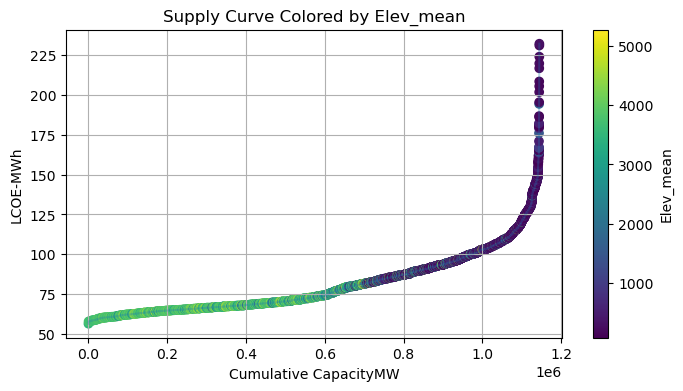

,LCOE-MWh,CapacityMW,Elev_mean,cumulative
0,56.526718,50.375424,3493.833333,5.037542e+01
1,57.940105,313.306656,3737.820000,3.636821e+02
2,58.023469,2222.553894,3721.452416,2.586236e+03
3,58.115389,840.974617,3717.501931,3.427211e+03
4,58.173328,2368.294102,3692.341564,5.795505e+03
...,...,...,...,...
2538,216.622472,27.137244,205.333333,1.144128e+06
2539,219.655893,36.680011,209.272727,1.144165e+06
2540,223.875484,127.336300,177.472222,1.144292e+06
2541,230.898565,92.445557,177.400000,1.144384e+06


In [297]:
#generate_supply_curve_color(geo_dataframe=gdf3solar,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="TD_Dist_gf", ascending=True)
generate_supply_curve_color(geo_dataframe=gdf3solar,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ascending=True)

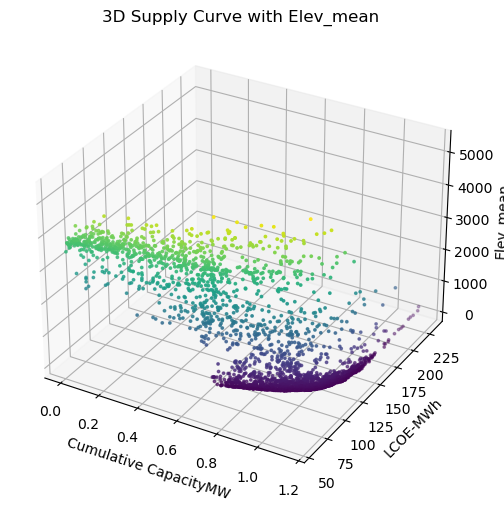

,LCOE-MWh,CapacityMW,Elev_mean,cumulative
0,56.526718,50.375424,3493.833333,5.037542e+01
1,57.940105,313.306656,3737.820000,3.636821e+02
2,58.023469,2222.553894,3721.452416,2.586236e+03
3,58.115389,840.974617,3717.501931,3.427211e+03
4,58.173328,2368.294102,3692.341564,5.795505e+03
...,...,...,...,...
2538,216.622472,27.137244,205.333333,1.144128e+06
2539,219.655893,36.680011,209.272727,1.144165e+06
2540,223.875484,127.336300,177.472222,1.144292e+06
2541,230.898565,92.445557,177.400000,1.144384e+06


In [298]:
generate_supply_curve_3d(geo_dataframe=gdf3solar, ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ascending=True)

C:\Users\Carlos\AppData\Local\Temp\ipykernel_36884\2190700042.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cmap, n_bands)


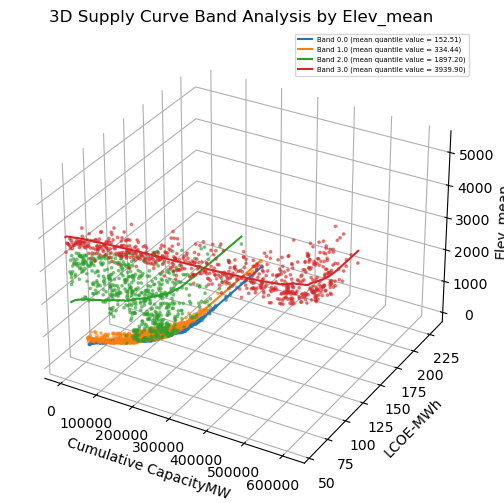

In [299]:
data_test = generate_supply_curve_3d_band_analysis(geo_dataframe=gdf3solar, 
                                       ranking_col="LCOE-MWh",
                                       accumulation_col="CapacityMW",
                                       third_col="Elev_mean", 
                                       n_bands=4, ascending=True, 
                                       cmap="viridis")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_36884\3988394567.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap(cmap, n_bands)


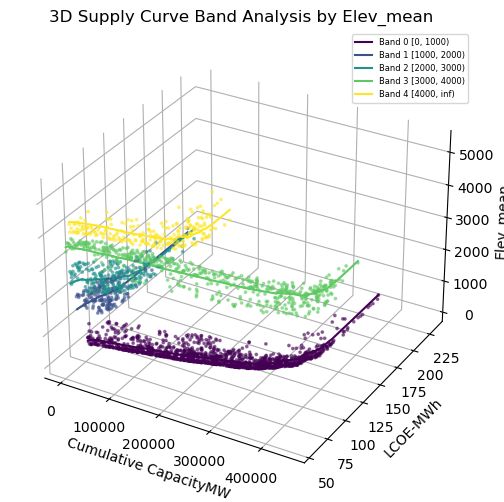

,LCOE-MWh,CapacityMW,Elev_mean,band
0,65.960954,1936.678637,3848.837521,3
1,69.031600,77.875797,3825.782609,3
2,68.021081,2282.940704,3902.084527,3
3,71.588476,2016.303129,4135.225122,4
4,70.112578,2352.811449,4095.151307,4
...,...,...,...,...
2538,137.057080,35.785377,3576.769231,3
2539,120.551667,20.874803,3811.200000,3
2540,175.971484,41.153184,1496.916667,1
2541,194.300288,20.278380,1658.200000,1


In [300]:
band_edges = [0, 1000, 2000, 3000, 4000, np.inf]

generate_supply_curve_3d_definedband_analysis(
    geo_dataframe=gdf3solar,
    ranking_col="LCOE-MWh",
    accumulation_col="CapacityMW",
    third_col="Elev_mean",
    band_edges=band_edges
)


## Data analysis (for screened or s4 data)

In [301]:
gdf4wind = gpd.read_file(S4_MSR_wind_file)
gdf4solar = gpd.read_file(S4_MSR_pv_file)

#check cordinate reference system and change it to WGS84 ellipsoid
gdf4wind = gdf4wind.to_crs("EPSG:4326")
gdf4solar = gdf4solar.to_crs("EPSG:4326")
#gdf4solar.crs

In [302]:
gdf4solar.info()
gdf4solar.columns
#gdf3wind.info()
#gdf3wind.columns

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         173 non-null    int64   
 1   AreakM2     173 non-null    float64 
 2   CapacityMW  173 non-null    float64 
 3   RoadDist    173 non-null    float64 
 4   T_Dist_gf   173 non-null    float64 
 5   D_Dist_gf   173 non-null    float64 
 6   TD_Dist_gf  173 non-null    float64 
 7   SubstnDist  173 non-null    float64 
 8   Load_dst    173 non-null    float64 
 9   City_name   173 non-null    object  
 10  City_Pop    173 non-null    float64 
 11  CtLst100kM  165 non-null    object  
 12  CtCnt100kM  173 non-null    int64   
 13  PopIn100kM  173 non-null    float64 
 14  Elev_mean   172 non-null    float64 
 15  Elev_max    172 non-null    float64 
 16  Elev_centr  173 non-null    float64 
 17  CtryName    173 non-null    object  
 18  GHIkWhm2d   173 non-null    object  
 19  

Index(['FID', 'AreakM2', 'CapacityMW', 'RoadDist', 'T_Dist_gf', 'D_Dist_gf',
       'TD_Dist_gf', 'SubstnDist', 'Load_dst', 'City_name', 'City_Pop',
       'CtLst100kM', 'CtCnt100kM', 'PopIn100kM', 'Elev_mean', 'Elev_max',
       'Elev_centr', 'CtryName', 'GHIkWhm2d', 'RawERA_GHI', 'CorAdderWh', 'CF',
       'Y_GWh', 'sLCOE-MWh', 'tLCOE-MWh', 'tCAPEX-kW', 'rLCOE-MWh',
       'rCAPEX-kW', 'LCOE-MWh', 'trCAPEX-kW', 'geometry'],
      dtype='object')

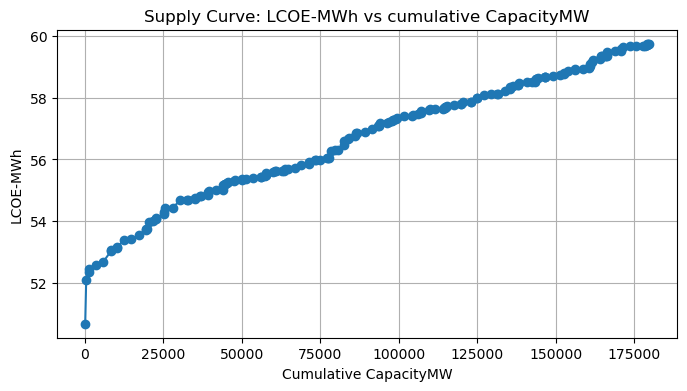

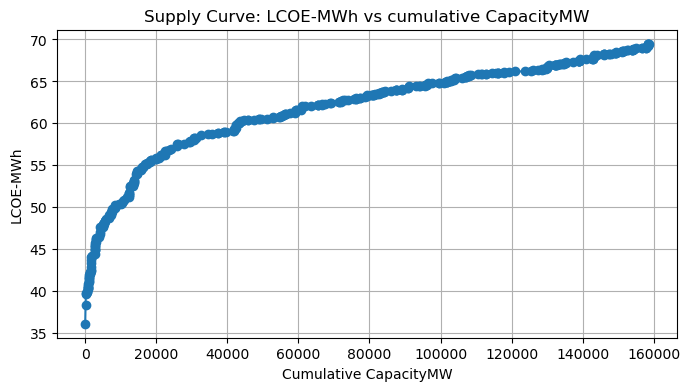

In [303]:
generate_supply_curve(geo_dataframe=gdf4solar,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",ascending=True)
generate_supply_curve(geo_dataframe=gdf4wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",ascending=True)

## Sensitivity analysis of supply curves

In [304]:
#Load prescreened MSR shapes for sensitivy analysis (with LCOE and CAPEX values defined) 
S3_MSR_pv_file_2021 = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_localcosts2021\SolarPV_prescreen.shp'
S3_MSR_wind_file_2021 = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_localcosts2021\Wind_prescreen.shp'

S3_MSR_pv_file_2050 = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_localcosts2050\SolarPV_prescreen.shp'
S3_MSR_wind_file_2050 = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia_localcosts2050\Wind_prescreen.shp'

In [305]:
gdf3wind2021 = gpd.read_file(S3_MSR_wind_file_2021)
gdf3solar2021 = gpd.read_file(S3_MSR_pv_file_2021)

gdf3wind2050 = gpd.read_file(S3_MSR_wind_file_2050)
gdf3solar2050 = gpd.read_file(S3_MSR_pv_file_2050)

In [306]:
def generate_supply_curve_color_modified(
    geo_dataframe, ranking_col, accumulation_col, third_col,
    ascending=True, cmap="viridis", ax=None, label=None, linestyle="-", marker="o", scatter_size=15
):
    df = geo_dataframe[[ranking_col, accumulation_col, third_col]].copy()
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)
    df["cumulative"] = df[accumulation_col].cumsum()

    # Create axis only if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    sc = ax.scatter(
        df["cumulative"],
        df[ranking_col],
        c=df[third_col],
        cmap=cmap,
        s=scatter_size,
        alpha=0.7,
        marker=marker,
        label=label
    )

    # ax.plot(
    #     df["cumulative"],
    #     df[ranking_col],
    #     linestyle=linestyle,
    #     linewidth=1.5,
    #     alpha=0.9,
    #     label=label
    # )

    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(ranking_col)
    ax.grid(True)

    return df, sc


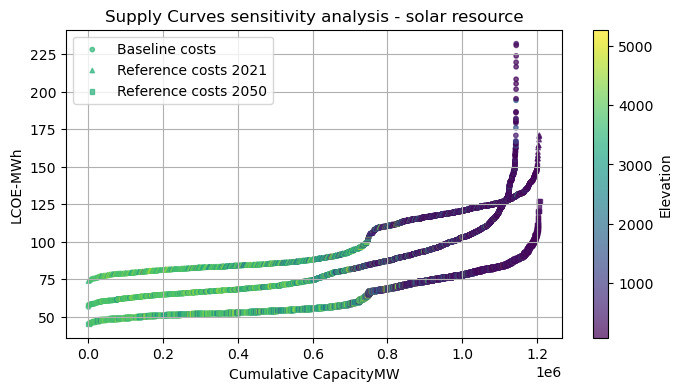

In [307]:
fig, ax = plt.subplots(figsize=(8, 4))

df1, sc1 = generate_supply_curve_color_modified(geo_dataframe=gdf3solar,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Baseline costs", marker="o", linestyle="-", scatter_size=10,ascending=True)
df2, sc2 = generate_supply_curve_color_modified(geo_dataframe=gdf3solar2021,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Reference costs 2021", marker="^", linestyle="--", scatter_size=10,ascending=True)
df3, sc3 = generate_supply_curve_color_modified(geo_dataframe=gdf3solar2050,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Reference costs 2050", marker="s", linestyle=":", scatter_size=10, ascending=True)

# One shared colorbar (use last scatter)
cbar = plt.colorbar(sc3, ax=ax)
cbar.set_label("Elevation")

ax.set_title("Supply Curves sensitivity analysis - solar resource")
ax.legend()
plt.show()

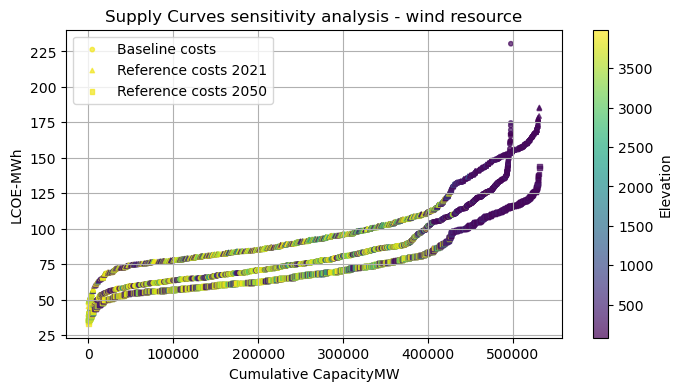

In [308]:
fig, ax = plt.subplots(figsize=(8, 4))

df1, sc1 = generate_supply_curve_color_modified(geo_dataframe=gdf3wind,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Baseline costs", marker="o", linestyle="-", scatter_size=10,ascending=True)
df2, sc2 = generate_supply_curve_color_modified(geo_dataframe=gdf3wind2021,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Reference costs 2021", marker="^", linestyle="--", scatter_size=10,ascending=True)
df3, sc3 = generate_supply_curve_color_modified(geo_dataframe=gdf3wind2050,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",third_col="Elev_mean", ax=ax,label="Reference costs 2050", marker="s", linestyle=":", scatter_size=10, ascending=True)

# One shared colorbar (use last scatter)
cbar = plt.colorbar(sc3, ax=ax)
cbar.set_label("Elevation")

ax.set_title("Supply Curves sensitivity analysis - wind resource")
ax.legend()
plt.show()

# LCOE and CAPEX comparisson

In [325]:
print("Min wind LCOE: " + str(gdf3wind["LCOE-MWh"].min()))
print("Max wind LCOE: " + str(gdf3wind["LCOE-MWh"].max()))
print("Average wind LCOE: " + str(gdf3wind["LCOE-MWh"].mean()))
print("Min solar LCOE: " + str(gdf3solar["LCOE-MWh"].min()))
print("Max solar LCOE: " + str(gdf3solar["LCOE-MWh"].max()))
print("Average solar LCOE: " + str(gdf3solar["LCOE-MWh"].mean())) 

Min wind LCOE: 35.117357523444745
Max wind LCOE: 230.48269432619625
Average wind LCOE: 85.91102712852266
Min solar LCOE: 56.52671758707807
Max solar LCOE: 232.00527092435604
Average solar LCOE: 94.70856765690604


In [326]:
print("Average solar Transmission line expansion LCOE: " + str(gdf3solar["tLCOE-MWh"].mean())) 
print("Average solar Road expansion LCOE:              " + str(gdf3solar["rLCOE-MWh"].mean())) 
print("Average solar Capacity expansion LCOE:          " + str(gdf3solar["sLCOE-MWh"].mean())) 
print("Average solar LCOE:                             " + str(gdf3solar["LCOE-MWh"].mean())) 

print("Average wind Transmission line expansion LCOE:  " + str(gdf3wind["tLCOE-MWh"].mean())) 
print("Average wind Road expansion LCOE:               " + str(gdf3wind["rLCOE-MWh"].mean())) 
print("Average wind Capacity expansion LCOE:           " + str(gdf3wind["sLCOE-MWh"].mean())) 
print("Average wind LCOE:                              " + str(gdf3wind["LCOE-MWh"].mean())) 

Average solar Transmission line expansion LCOE: 16.212444922427526
Average solar Road expansion LCOE:              10.837402522816385
Average solar Capacity expansion LCOE:          67.65872021166214
Average solar LCOE:                             94.70856765690604
Average wind Transmission line expansion LCOE:  7.931161749626289
Average wind Road expansion LCOE:               5.8215105298429775
Average wind Capacity expansion LCOE:           72.1583548490534
Average wind LCOE:                              85.91102712852266


In [332]:
print("Min wind CAPEX: "        + str(gdf3wind["TotalCAPEX"].min()))
print("Max wind CAPEX: "        + str(gdf3wind["TotalCAPEX"].max()))
print("Average wind CAPEX: "    + str(gdf3wind["TotalCAPEX"].mean()))

print("Min T&R wind CAPEX: "        + str(gdf3wind["trCAPEX-kW"].min()))
print("Max T&R wind CAPEX: "        + str(gdf3wind["trCAPEX-kW"].max()))
print("Average T&R wind CAPEX: "    + str(gdf3wind["trCAPEX-kW"].mean()))

Min wind CAPEX: 139.01291371407913
Max wind CAPEX: 380.5067366738457
Average wind CAPEX: 200.67052589795782
Min T&R wind CAPEX: 9.509622701486604
Max T&R wind CAPEX: 213.5306469348138
Average T&R wind CAPEX: 36.13964482023272


In [ ]:
print("Min solar CAPEX: "       + str(gdf3solar["TotalCAPEX"].min()))
print("Max solar CAPEX: "       + str(gdf3solar["TotalCAPEX"].max()))
print("Average solar CAPEX: "   + str(gdf3solar["TotalCAPEX"].mean())) 

print("Min T&R solar CAPEX: "        + str(gdf3solar["trCAPEX-kW"].min()))
print("Max T&R solar CAPEX: "        + str(gdf3solar["trCAPEX-kW"].max()))
print("Average T&R solar CAPEX: "    + str(gdf3solar["trCAPEX-kW"].mean()))

Min solar CAPEX: 87.30200106493248
Max solar CAPEX: 318.7158350132436
Average solar CAPEX: 121.51636401573317
Min T&R solar CAPEX: 8.752165593447632
Max T&R solar CAPEX: 240.1659995417587
Average T&R solar CAPEX: 42.966528544248305
